# Entrenamiento de Modelo BiLSTM para Clasificación de Arritmias Cardíacas

Implementa un modelo BiLSTM para clasificación de 5 clases según el estándar **ANSI/AAMI EC57**.

**Dataset:** MIT-BIH Arrhythmia Database  
**Clases:** Normal / SVEB / VEB / Fusion / Unknown  
**Modelo:** BiLSTM de 2 capas (128/64 unidades) + BatchNorm + Capas Densas  
**Framework:** PyTorch

## 1. Instalación de Dependencias

In [1]:
import warnings
warnings.filterwarnings('ignore')

!pip install wfdb numpy torch matplotlib scikit-learn seaborn -q

## 2. Importación de Librerías

In [2]:
import wfdb
import numpy as np
import pandas as pd
from collections import Counter
import pickle, os
from datetime import datetime

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, recall_score, f1_score, precision_score,
    roc_curve, auc
)
from sklearn.utils.class_weight import compute_class_weight

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Dispositivo: cuda
GPU: Tesla T4


## 3. Configuración de Hiperparámetros

In [3]:
# ==================== PARÁMETROS DEL MODELO ====================
INPUT_SIZE    = 1
HIDDEN_SIZE_1 = 128
HIDDEN_SIZE_2 = 64
NUM_CLASSES   = 5

# ==================== PARÁMETROS DE ENTRENAMIENTO ====================
BATCH_SIZE              = 32
LEARNING_RATE           = 0.001
NUM_EPOCHS              = 100
EARLY_STOPPING_PATIENCE = 15
REDUCE_LR_PATIENCE      = 5

# ==================== PARÁMETROS DE SEÑAL ====================
WINDOW_SIZE     = 180
SAMPLING_RATE   = 360
WINDOW_DURATION = WINDOW_SIZE / SAMPLING_RATE

# ==================== RUTAS ====================
DATASET_PATH = './mitdb'
MODEL_PATH   = 'bilstm_ecg_aami.pth'
SCALER_PATH  = 'scaler.pkl'
ENCODER_PATH = 'label_encoder.pkl'

print('Configuración cargada')
print(f'Ventana  : {WINDOW_SIZE} muestras ({WINDOW_DURATION:.2f} s)')
print(f'Clases   : {NUM_CLASSES} (Normal / SVEB / VEB / Fusion / Unknown)')
print(f'Épocas   : {NUM_EPOCHS}')

Configuración cargada
Ventana  : 180 muestras (0.50 s)
Clases   : 5 (Normal / SVEB / VEB / Fusion / Unknown)
Épocas   : 100


## 4. Mapeo MIT-BIH → ANSI/AAMI EC57

| Símbolo MIT-BIH | Descripción | Clase AAMI |
|---|---|---|
| N, L, R, e, j | Normal y variantes fisiológicas | Normal |
| A, a, J, S | Latidos ectópicos supraventriculares | SVEB |
| V, E | Latidos ectópicos ventriculares | VEB |
| F | Fusión ventricular-normal | Fusion |
| /, f, Q, ! | Marcapasos / no clasificables | Unknown |

In [4]:
MITBIH_TO_AAMI = {
    'N':'Normal','L':'Normal','R':'Normal','e':'Normal','j':'Normal',
    'A':'SVEB','a':'SVEB','J':'SVEB','S':'SVEB',
    'V':'VEB','E':'VEB',
    'F':'Fusion',
    '/':'Unknown','f':'Unknown','Q':'Unknown','!':'Unknown',
}

CLASS_NAMES           = ['Normal', 'SVEB', 'VEB', 'Fusion', 'Unknown']
CLASS_MAPPING         = {name: idx for idx, name in enumerate(CLASS_NAMES)}
REVERSE_CLASS_MAPPING = {idx: name for name, idx in CLASS_MAPPING.items()}

print('Mapeo AAMI EC57 configurado')
print(f'Clases: {CLASS_NAMES}')

Mapeo AAMI EC57 configurado
Clases: ['Normal', 'SVEB', 'VEB', 'Fusion', 'Unknown']


## 5. Descarga del Dataset MIT-BIH

In [5]:
print('Descargando MIT-BIH Arrhythmia Database...')
wfdb.dl_database('mitdb', DATASET_PATH)

files   = os.listdir(DATASET_PATH)
records = sorted(set([f.split('.')[0] for f in files if '.' in f]))
print(f'Registros: {len(records)}  |  Ubicación: {DATASET_PATH}')

Descargando MIT-BIH Arrhythmia Database...
Generating record list for: 100
Generating record list for: 101
Generating record list for: 102
Generating record list for: 103
Generating record list for: 104
Generating record list for: 105
Generating record list for: 106
Generating record list for: 107
Generating record list for: 108
Generating record list for: 109
Generating record list for: 111
Generating record list for: 112
Generating record list for: 113
Generating record list for: 114
Generating record list for: 115
Generating record list for: 116
Generating record list for: 117
Generating record list for: 118
Generating record list for: 119
Generating record list for: 121
Generating record list for: 122
Generating record list for: 123
Generating record list for: 124
Generating record list for: 200
Generating record list for: 201
Generating record list for: 202
Generating record list for: 203
Generating record list for: 205
Generating record list for: 207
Generating record list for: 2

## 6. Funciones de Carga y Segmentación

In [6]:
def load_record(record_number, dataset_path=DATASET_PATH):
    """
    Carga un registro MIT-BIH con su señal ECG y anotaciones.
    Returns: (signal, symbols, samples, fs) o (None,...) si hay error.
    """
    try:
        record     = wfdb.rdrecord(f'{dataset_path}/{record_number}')
        annotation = wfdb.rdann(f'{dataset_path}/{record_number}', 'atr')
        signal = record.p_signal[:, 0] if record.p_signal.ndim > 1 else record.p_signal
        if record.fs != SAMPLING_RATE:
            n_orig   = len(signal)
            n_target = int(n_orig * SAMPLING_RATE / record.fs)
            signal   = np.interp(np.linspace(0, n_orig-1, n_target), np.arange(n_orig), signal)
        return signal, annotation.symbol, annotation.sample, record.fs
    except Exception as e:
        print(f'  Error en registro {record_number}: {e}')
        return None, None, None, None


def segment_signal(signal, symbols, samples, window_size=WINDOW_SIZE):
    """
    Segmenta la señal ECG en ventanas de window_size muestras
    centradas en el pico R de cada latido anotado.
    Returns: (segments, labels) con clase AAMI correspondiente.
    """
    segments, labels = [], []
    half = window_size // 2
    for i in range(len(symbols)):
        beat_pos = samples[i]
        start, end = beat_pos - half, beat_pos + half
        if start < 0 or end >= len(signal): continue
        segment = signal[start:end]
        if len(segment) != window_size: continue
        aami_class = MITBIH_TO_AAMI.get(symbols[i])
        if aami_class is not None:
            segments.append(segment)
            labels.append(aami_class)
    return segments, labels


print('Funciones de procesamiento definidas')

Funciones de procesamiento definidas


### Figura — Ventana de segmentación
Ilustra el proceso de extracción de una ventana de 180 muestras centrada en el pico R.

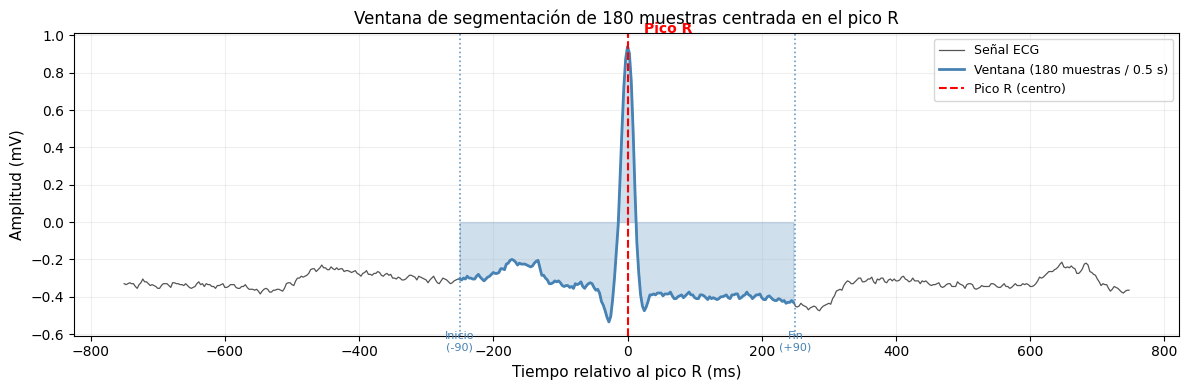

fig_segmentation_window.png guardada


In [7]:
# Cargar un latido Normal del registro 100 para ilustrar la segmentación
_rec  = wfdb.rdrecord('./mitdb/100')
_ann  = wfdb.rdann('./mitdb/100', 'atr')
_sig  = _rec.p_signal[:, 0]
_fs   = _rec.fs
_half = 90

_beat_idx = next(i for i, s in enumerate(_ann.symbol)
                 if s == 'N' and _ann.sample[i] > 270)
_beat_pos = _ann.sample[_beat_idx]

# Contexto: ±0.75 s
_ctx     = 270
_t_ctx   = np.arange(-_ctx, _ctx) / _fs * 1000
_sig_ctx = _sig[_beat_pos - _ctx : _beat_pos + _ctx]
_t_win   = np.arange(-_half, _half) / _fs * 1000
_sig_win = _sig[_beat_pos - _half : _beat_pos + _half]

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(_t_ctx, _sig_ctx, color='#555555', lw=0.9, label='Señal ECG')
ax.fill_between(_t_win, _sig_win, alpha=0.25, color='steelblue')
ax.plot(_t_win, _sig_win, color='steelblue', lw=2.0, label='Ventana (180 muestras / 0.5 s)')
ax.axvline(0, color='red', lw=1.5, ls='--', label='Pico R (centro)')
ax.annotate('Pico R', xy=(0, _sig[_beat_pos]), xytext=(12, 10),
            textcoords='offset points', color='red', fontsize=10, fontweight='bold')
for xv, lbl in [(-_half/_fs*1000, 'Inicio\n(-90)'), (_half/_fs*1000, 'Fin\n(+90)')]:
    ax.axvline(xv, color='steelblue', lw=1.2, ls=':', alpha=0.8)
    ax.text(xv, min(_sig_ctx)-0.05, lbl, ha='center', va='top', fontsize=8, color='steelblue')
ax.set_xlabel('Tiempo relativo al pico R (ms)', fontsize=11)
ax.set_ylabel('Amplitud (mV)', fontsize=11)
ax.set_title('Ventana de segmentación de 180 muestras centrada en el pico R', fontsize=12)
ax.legend(fontsize=9); ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig('fig_segmentation_window.png', dpi=300, bbox_inches='tight')
plt.show()
print('fig_segmentation_window.png guardada')

## 7. Carga y Procesamiento de Datos

In [8]:
print('Procesando registros MIT-BIH...\n')
all_segments, all_labels = [], []

files   = os.listdir(DATASET_PATH)
records = sorted(set([f.split('.')[0] for f in files if '.' in f]))

for record_num in records:
    signal, symbols, samples, fs = load_record(record_num)
    if signal is not None:
        segs, labs = segment_signal(signal, symbols, samples)
        all_segments.extend(segs)
        all_labels.extend(labs)
        print(f'  Registro {record_num}: {len(segs):,} segmentos')

print(f'\nTotal segmentos: {len(all_segments):,}')
label_counts = Counter(all_labels)
print('\nDistribución de clases:')
for label in CLASS_NAMES:
    count = label_counts.get(label, 0)
    pct   = count / len(all_labels) * 100
    print(f'  {label:8s}: {count:6,} ({pct:5.1f}%)')

Procesando registros MIT-BIH...

  Registro 100: 2,271 segmentos
  Registro 101: 1,864 segmentos
  Registro 102: 2,187 segmentos
  Registro 103: 2,084 segmentos
  Registro 104: 2,228 segmentos
  Registro 105: 2,572 segmentos
  Registro 106: 2,027 segmentos
  Registro 107: 2,137 segmentos
  Registro 108: 1,762 segmentos
  Registro 109: 2,531 segmentos
  Registro 111: 2,124 segmentos
  Registro 112: 2,539 segmentos
  Registro 113: 1,794 segmentos
  Registro 114: 1,879 segmentos
  Registro 115: 1,952 segmentos
  Registro 116: 2,411 segmentos
  Registro 117: 1,534 segmentos
  Registro 118: 2,277 segmentos
  Registro 119: 1,987 segmentos
  Registro 121: 1,863 segmentos
  Registro 122: 2,476 segmentos
  Registro 123: 1,517 segmentos
  Registro 124: 1,619 segmentos
  Registro 200: 2,600 segmentos
  Registro 201: 1,963 segmentos
  Registro 202: 2,136 segmentos
  Registro 203: 2,980 segmentos
  Registro 205: 2,656 segmentos
  Registro 207: 2,331 segmentos
  Registro 208: 2,953 segmentos
  Regis

### Figura — Señal ECG con anotaciones AAMI
Visualiza 5 segundos de la señal del registro 100 con los latidos anotados y coloreados por clase.

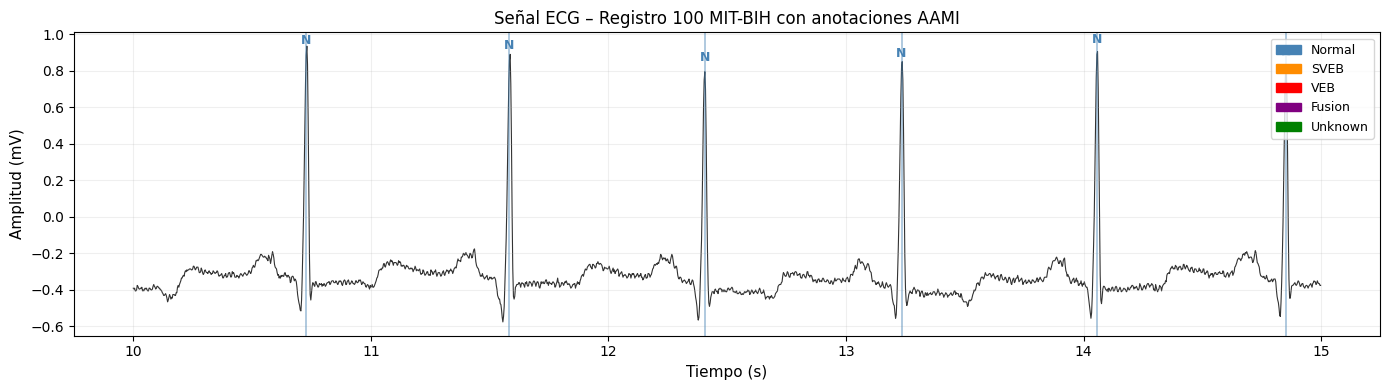

fig_ecg_signal.png guardada


In [9]:
_rec2 = wfdb.rdrecord("./mitdb/100")
_ann2 = wfdb.rdann("./mitdb/100", "atr")
_sig2 = _rec2.p_signal[:, 0]
_fs2 = _rec2.fs

t_start, t_end = 10, 15
s_start, s_end = t_start * _fs2, t_end * _fs2
_t = [i / _fs2 for i in range(s_start, s_end)]

color_map = {
    "N": "steelblue",
    "L": "steelblue",
    "R": "steelblue",
    "e": "steelblue",
    "j": "steelblue",
    "A": "darkorange",
    "a": "darkorange",
    "J": "darkorange",
    "S": "darkorange",
    "V": "red",
    "E": "red",
    "F": "purple",
    "/": "green",
    "f": "green",
    "Q": "gray",
    "!": "gray",
}

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(_t, _sig2[s_start:s_end], color="#333333", lw=0.8, zorder=1)

for sym, samp in zip(_ann2.symbol, _ann2.sample):
    if s_start <= samp < s_end:
        t_beat = samp / _fs2
        color = color_map.get(sym, "gray")
        ax.axvline(t_beat, color=color, alpha=0.5, lw=1.2, zorder=2)
        ax.annotate(
            sym,
            xy=(t_beat, _sig2[samp]),
            xytext=(0, 8),
            textcoords="offset points",
            ha="center",
            fontsize=9,
            color=color,
            fontweight="bold",
        )

patches = [
    mpatches.Patch(color="steelblue", label="Normal"),
    mpatches.Patch(color="darkorange", label="SVEB"),
    mpatches.Patch(color="red", label="VEB"),
    mpatches.Patch(color="purple", label="Fusion"),
    mpatches.Patch(color="green", label="Unknown"),
]
ax.legend(handles=patches, loc="upper right", fontsize=9)
ax.set_xlabel("Tiempo (s)", fontsize=11)
ax.set_ylabel("Amplitud (mV)", fontsize=11)
ax.set_title("Señal ECG – Registro 100 MIT-BIH con anotaciones AAMI", fontsize=12)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig("fig_ecg_signal.png", dpi=300, bbox_inches="tight")
plt.show()
print("fig_ecg_signal.png guardada")

## 8. Preprocesamiento
División estratificada **80/10/10**. El `StandardScaler` se ajusta **solo sobre train** para evitar data leakage.

In [10]:
X     = np.array(all_segments)
y_raw = np.array(all_labels)
print(f'Forma de X: {X.shape}  |  Forma de y: {y_raw.shape}')

# Codificación con orden explícito
label_encoder = LabelEncoder()
label_encoder.fit(CLASS_NAMES)
y_encoded = label_encoder.transform(y_raw)

# División ANTES de normalizar
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y_encoded, test_size=0.10, random_state=42, stratify=y_encoded)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1111, random_state=42, stratify=y_temp)

# Normalización ajustada SOLO sobre train
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

print(f'Train : {X_train.shape[0]:,} ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'Val   : {X_val.shape[0]:,} ({X_val.shape[0]/len(X)*100:.0f}%)')
print(f'Test  : {X_test.shape[0]:,} ({X_test.shape[0]/len(X)*100:.0f}%)')

# Class weights
class_weights = compute_class_weight('balanced', classes=np.arange(NUM_CLASSES), y=y_train)
class_weights_tensor = torch.FloatTensor(class_weights).to(device)
print('\nClass weights:')
for i, w in enumerate(class_weights):
    print(f'  {CLASS_NAMES[i]:8s}: {w:.4f}')

def to_tensor(X, y):
    return torch.FloatTensor(X).unsqueeze(-1), torch.LongTensor(y)

X_train_t, y_train_t = to_tensor(X_train, y_train)
X_val_t,   y_val_t   = to_tensor(X_val,   y_val)
X_test_t,  y_test_t  = to_tensor(X_test,  y_test)

Forma de X: (109940, 180)  |  Forma de y: (109940,)
Train : 87,953 (80%)
Val   : 10,993 (10%)
Test  : 10,994 (10%)

Class weights:
  Normal  : 27.3997
  SVEB    : 0.2427
  VEB     : 7.9059
  Fusion  : 2.5823
  Unknown : 3.0397


## 9. Dataset y DataLoader

In [11]:
class ECGDataset(Dataset):
    def __init__(self, features, labels):
        self.features, self.labels = features, labels
    def __len__(self): return len(self.features)
    def __getitem__(self, idx): return self.features[idx], self.labels[idx]

pin = torch.cuda.is_available()
train_loader = DataLoader(ECGDataset(X_train_t, y_train_t), batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=2, pin_memory=pin)
val_loader   = DataLoader(ECGDataset(X_val_t,   y_val_t),   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=2, pin_memory=pin)
test_loader  = DataLoader(ECGDataset(X_test_t,  y_test_t),  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=2, pin_memory=pin)

print(f'Batches  train={len(train_loader)}  val={len(val_loader)}  test={len(test_loader)}')

Batches  train=2749  val=344  test=344


## 10. Definición del Modelo BiLSTM
```
Input (B,180,1) 
    → BiLSTM-1[128u] → BN 
    → BiLSTM-2[64u] → BN → último timestep
    → Dense 64 (ReLU) 
    → Dense 32 (ReLU) → Dense 5 (logits)
```

In [12]:
class BiLSTMModel(nn.Module):
    """
    BiLSTM de 2 capas con BatchNorm y capas densas para clasificación
    de 5 clases de arritmias según ANSI/AAMI EC57.
    """
    def __init__(self, input_size=1, hidden_size_1=128, hidden_size_2=64,
                 num_classes=5, dropout=0.3):
        super().__init__()
        self.lstm1  = nn.LSTM(input_size, hidden_size_1, batch_first=True, bidirectional=True)
        self.bn1    = nn.BatchNorm1d(hidden_size_1 * 2)
        self.drop1  = nn.Dropout(dropout)
        self.lstm2  = nn.LSTM(hidden_size_1*2, hidden_size_2, batch_first=True, bidirectional=True)
        self.bn2    = nn.BatchNorm1d(hidden_size_2 * 2)
        self.drop2  = nn.Dropout(dropout)
        self.fc1    = nn.Linear(hidden_size_2 * 2, 64)
        self.drop3  = nn.Dropout(0.4)
        self.fc2    = nn.Linear(64, 32)
        self.drop4  = nn.Dropout(dropout)
        self.fc_out = nn.Linear(32, num_classes)

    def _bn_seq(self, bn, x):
        """BatchNorm1d sobre salida LSTM (B,T,C) → (B,C,T) → BN → (B,T,C)."""
        return bn(x.permute(0,2,1)).permute(0,2,1)

    def forward(self, x):
        out, _ = self.lstm1(x)
        out    = self.drop1(self._bn_seq(self.bn1, out))
        out, _ = self.lstm2(out)
        out    = self.drop2(self._bn_seq(self.bn2, out))
        out    = out[:, -1, :]
        out    = self.drop3(torch.relu(self.fc1(out)))
        out    = self.drop4(torch.relu(self.fc2(out)))
        return self.fc_out(out)


model = BiLSTMModel(INPUT_SIZE, HIDDEN_SIZE_1, HIDDEN_SIZE_2, NUM_CLASSES).to(device)
print(model)
print(f'\nParámetros totales: {sum(p.numel() for p in model.parameters()):,}')

BiLSTMModel(
  (lstm1): LSTM(1, 128, batch_first=True, bidirectional=True)
  (bn1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (drop1): Dropout(p=0.3, inplace=False)
  (lstm2): LSTM(256, 64, batch_first=True, bidirectional=True)
  (bn2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (drop2): Dropout(p=0.3, inplace=False)
  (fc1): Linear(in_features=128, out_features=64, bias=True)
  (drop3): Dropout(p=0.4, inplace=False)
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (drop4): Dropout(p=0.3, inplace=False)
  (fc_out): Linear(in_features=32, out_features=5, bias=True)
)

Parámetros totales: 310,277


## 11. Configuración de Entrenamiento

In [13]:
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, betas=(0.9,0.999), eps=1e-7)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=REDUCE_LR_PATIENCE)

print(f'Optimizador : Adam (lr={LEARNING_RATE}, beta1=0.9, beta2=0.999, eps=1e-7)')
print(f'Loss        : CrossEntropyLoss con class weights')
print(f'Scheduler   : ReduceLROnPlateau (patience={REDUCE_LR_PATIENCE})')

Optimizador : Adam (lr=0.001, beta1=0.9, beta2=0.999, eps=1e-7)
Loss        : CrossEntropyLoss con class weights
Scheduler   : ReduceLROnPlateau (patience=5)


## 12. Loop de Entrenamiento

In [14]:
def run_epoch(model, loader, criterion, optimizer, device, train=True):
    model.train() if train else model.eval()
    total_loss, all_preds, all_targets = 0, [], []
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for X_b, y_b in loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            if train: optimizer.zero_grad()
            logits = model(X_b)
            loss   = criterion(logits, y_b)
            if train: loss.backward(); optimizer.step()
            total_loss += loss.item()
            all_preds.extend(logits.argmax(dim=1).cpu().numpy())
            all_targets.extend(y_b.cpu().numpy())
    avg_loss = total_loss / len(loader)
    acc   = accuracy_score(all_targets, all_preds)
    rec   = recall_score(all_targets, all_preds, average='macro', zero_division=0)
    f1    = f1_score(all_targets, all_preds, average='macro', zero_division=0)
    prec  = precision_score(all_targets, all_preds, average='macro', zero_division=0)
    return avg_loss, acc, rec, f1, prec


print('='*70)
print('INICIANDO ENTRENAMIENTO')
print('='*70)

history = {k: [] for k in ['train_loss','val_loss','val_acc','val_recall','val_f1','val_prec']}
best_val_f1, patience_counter = 0.0, 0
start_time = datetime.now()

for epoch in range(NUM_EPOCHS):
    t_loss, *_ = run_epoch(model, train_loader, criterion, optimizer, device, train=True)
    v_loss, v_acc, v_rec, v_f1, v_prec = run_epoch(
        model, val_loader, criterion, optimizer, device, train=False)
    scheduler.step(v_loss)
    for k, v in zip(history.keys(), [t_loss, v_loss, v_acc, v_rec, v_f1, v_prec]):
        history[k].append(v)
    print(f'Ep [{epoch+1:3d}/{NUM_EPOCHS}] '
          f'TLoss:{t_loss:.4f}  VLoss:{v_loss:.4f}  '
          f'Acc:{v_acc:.4f}  Prec:{v_prec:.4f}  Recall:{v_rec:.4f}  F1:{v_f1:.4f}')
    if v_f1 > best_val_f1:
        best_val_f1 = v_f1
        torch.save(model.state_dict(), MODEL_PATH)
        print(f'    >> Modelo guardado  (Val F1 macro: {v_f1:.4f})')
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= EARLY_STOPPING_PATIENCE:
            print(f'Early stopping en época {epoch+1}')
            break

print(f'\nTiempo total: {datetime.now()-start_time}  |  Mejor F1 macro: {best_val_f1:.4f}')

INICIANDO ENTRENAMIENTO
Ep [  1/100] TLoss:1.4448  VLoss:1.2697  Acc:0.1810  Prec:0.2639  Recall:0.4544  F1:0.1771
    >> Modelo guardado  (Val F1 macro: 0.1771)
Ep [  2/100] TLoss:1.2782  VLoss:1.1413  Acc:0.4575  Prec:0.3582  Recall:0.5181  F1:0.3252
    >> Modelo guardado  (Val F1 macro: 0.3252)
Ep [  3/100] TLoss:1.1815  VLoss:0.9174  Acc:0.5290  Prec:0.4116  Recall:0.6394  F1:0.4108
    >> Modelo guardado  (Val F1 macro: 0.4108)
Ep [  4/100] TLoss:1.0519  VLoss:0.9158  Acc:0.5408  Prec:0.4520  Recall:0.6327  F1:0.4395
    >> Modelo guardado  (Val F1 macro: 0.4395)
Ep [  5/100] TLoss:0.9833  VLoss:0.7600  Acc:0.5598  Prec:0.5005  Recall:0.6892  F1:0.4772
    >> Modelo guardado  (Val F1 macro: 0.4772)
Ep [  6/100] TLoss:0.8636  VLoss:0.7502  Acc:0.6840  Prec:0.4841  Recall:0.6929  F1:0.5080
    >> Modelo guardado  (Val F1 macro: 0.5080)
Ep [  7/100] TLoss:0.8419  VLoss:0.6127  Acc:0.7723  Prec:0.5312  Recall:0.7506  F1:0.5575
    >> Modelo guardado  (Val F1 macro: 0.5575)
Ep [  8/10

### Figura — Curvas de entrenamiento
Generada inmediatamente después del loop para verificar convergencia y ausencia de sobreajuste.

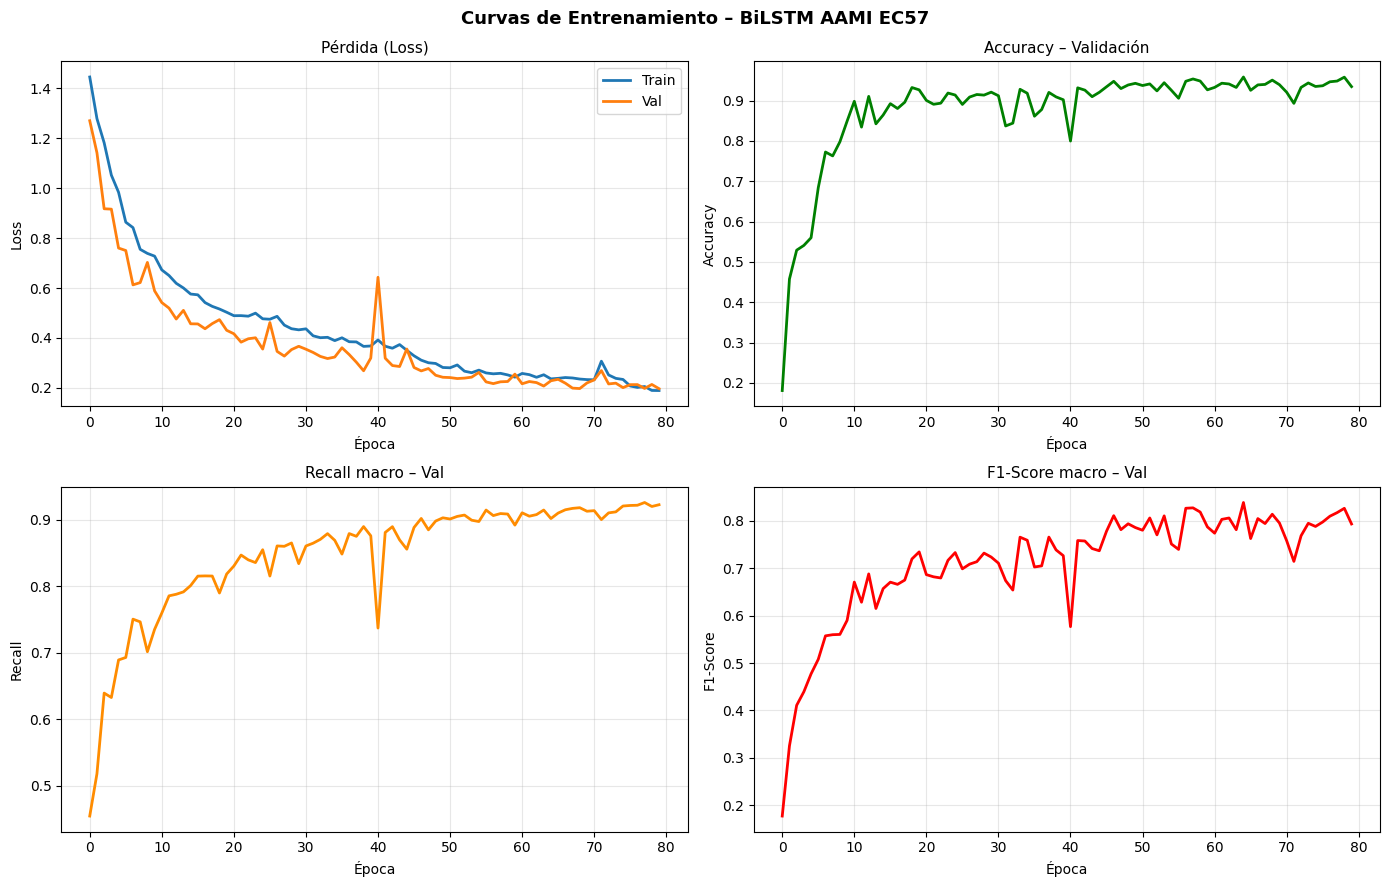

fig_training_curves.png guardada


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle(
    "Curvas de Entrenamiento – BiLSTM AAMI EC57", fontsize=13, fontweight="bold"
)

cfg = [
    ("train_loss", "val_loss", "Pérdida (Loss)", "Loss", None),
    ("val_acc", None, "Accuracy – Validación", "Accuracy", "green"),
    ("val_recall", None, "Recall macro – Val", "Recall", "darkorange"),
    ("val_f1", None, "F1-Score macro – Val", "F1-Score", "red"),
]
for ax, (k1, k2, title, ylabel, color) in zip(axes.flat, cfg):
    if k2:
        ax.plot(history[k1], lw=2, label="Train")
        ax.plot(history[k2], lw=2, label="Val")
        ax.legend()
    else:
        ax.plot(history[k1], color=color, lw=2)
    ax.set_title(title, fontsize=11)    
    ax.set_xlabel("Época")
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("fig_training_curves.png", dpi=300, bbox_inches="tight")
plt.show()
print("fig_training_curves.png guardada")

## 13. Evaluación Final en Conjunto de Test
El conjunto de test no participó en ninguna etapa de entrenamiento ni selección del modelo.

In [16]:
print('='*70)
print('EVALUACIÓN FINAL (conjunto de TEST independiente)')
print('='*70)

model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.eval()

all_preds, all_targets = [], []
with torch.no_grad():
    for X_b, y_b in test_loader:
        preds = model(X_b.to(device)).argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(y_b.numpy())

print('\nREPORTE DE CLASIFICACIÓN:\n')
print(classification_report(all_targets, all_preds, target_names=CLASS_NAMES, zero_division=0))

print('MÉTRICAS FINALES (macro-average)')
print(f'  Accuracy  : {accuracy_score(all_targets, all_preds):.4f}')
print(f'  Precision : {precision_score(all_targets, all_preds, average="macro", zero_division=0):.4f}')
print(f'  Recall    : {recall_score(all_targets, all_preds, average="macro", zero_division=0):.4f}')
print(f'  F1-Score  : {f1_score(all_targets, all_preds, average="macro", zero_division=0):.4f}')

EVALUACIÓN FINAL (conjunto de TEST independiente)

REPORTE DE CLASIFICACIÓN:

              precision    recall  f1-score   support

      Normal       0.65      0.81      0.72        80
        SVEB       0.99      0.96      0.98      9061
         VEB       0.52      0.82      0.64       278
      Fusion       0.96      0.99      0.97       851
     Unknown       0.86      0.95      0.90       724

    accuracy                           0.96     10994
   macro avg       0.80      0.91      0.84     10994
weighted avg       0.97      0.96      0.96     10994

MÉTRICAS FINALES (macro-average)
  Accuracy  : 0.9572
  Precision : 0.7950
  Recall    : 0.9066
  F1-Score  : 0.8417


### Figura — Matriz de confusión  y Figura — Curvas ROC
Generadas sobre los mismos `all_targets` y `all_preds` de la evaluación anterior.

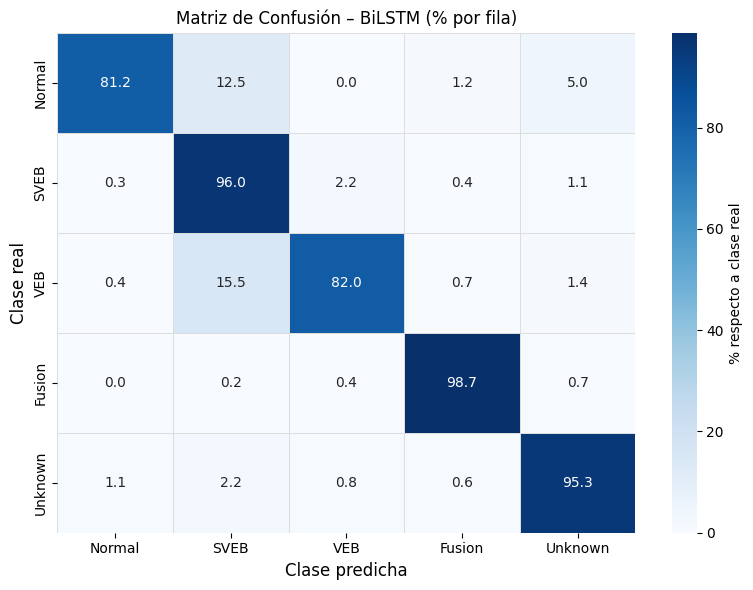

fig_confusion_matrix.png guardada


In [ ]:
# ── Figura: Matriz de confusión normalizada ──────────────────────────────
cm     = confusion_matrix(all_targets, all_preds)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            linewidths=0.5, linecolor='#DDDDDD',
            cbar_kws={'label': '% respecto a clase real'}, ax=ax)
ax.set_xlabel('Clase predicha',  fontsize=12)
ax.set_ylabel('Clase real',      fontsize=12)
ax.set_title('Matriz de Confusión – BiLSTM (% por fila)', fontsize=12)
plt.tight_layout()
plt.savefig('fig_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()
print('fig_confusion_matrix.png guardada')

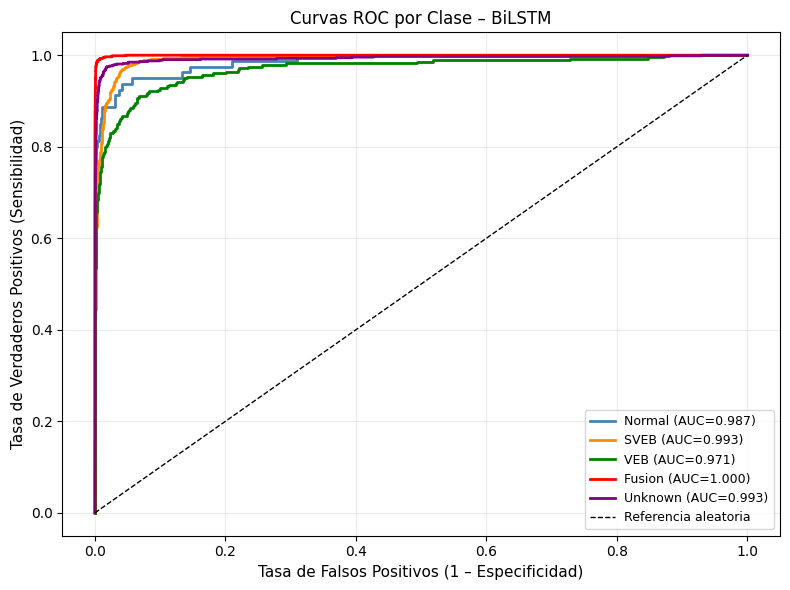

fig_roc_curves.png guardada


In [ ]:
# ── Figura: Curvas ROC por clase ────────────────────────────────────────
y_bin = label_binarize(all_targets, classes=range(NUM_CLASSES))

probs = []
with torch.no_grad():
    for X_b, _ in test_loader:
        logits = model(X_b.to(device))
        probs.extend(torch.softmax(logits, dim=1).cpu().numpy())
probs = np.array(probs)

colors = ['steelblue','darkorange','green','red','purple']
fig, ax = plt.subplots(figsize=(8, 6))
for i, (name, color) in enumerate(zip(CLASS_NAMES, colors)):
    fpr, tpr, _ = roc_curve(y_bin[:, i], probs[:, i])
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC={auc(fpr,tpr):.3f})')
ax.plot([0,1],[0,1],'k--', lw=1, label='Referencia aleatoria')
ax.set_xlabel('Tasa de Falsos Positivos (1 – Especificidad)', fontsize=11)
ax.set_ylabel('Tasa de Verdaderos Positivos (Sensibilidad)',  fontsize=11)
ax.set_title('Curvas ROC por Clase – BiLSTM', fontsize=12)
ax.legend(loc='lower right', fontsize=9); ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig('fig_roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()
print('fig_roc_curves.png guardada')

## 14. Guardar Artefactos

In [19]:
with open(SCALER_PATH,  'wb') as f: pickle.dump(scaler,        f)
with open(ENCODER_PATH, 'wb') as f: pickle.dump(label_encoder, f)

print('Artefactos guardados:')
print(f'  Modelo        : {MODEL_PATH}')
print(f'  Scaler        : {SCALER_PATH}')
print(f'  Label Encoder : {ENCODER_PATH}')
print()
print('Especificaciones para deployment:')
print(f'  Input  : {WINDOW_SIZE} muestras ({WINDOW_DURATION:.2f}s @ {SAMPLING_RATE}Hz) → shape (1,{WINDOW_SIZE},1)')
print(f'  Output : {NUM_CLASSES} clases → {CLASS_NAMES}')
print(f'  Pre-procesamiento: aplicar scaler.pkl antes de inferencia')

Artefactos guardados:
  Modelo        : bilstm_ecg_aami.pth
  Scaler        : scaler.pkl
  Label Encoder : label_encoder.pkl

Especificaciones para deployment:
  Input  : 180 muestras (0.50s @ 360Hz) → shape (1,180,1)
  Output : 5 clases → ['Normal', 'SVEB', 'VEB', 'Fusion', 'Unknown']
  Pre-procesamiento: aplicar scaler.pkl antes de inferencia
